In this notebook, I will code up the updated signal model. That is, treating the mean of the host DM as 0th order, so the change in the mean host DM is 1st order, and the change in host DM spread is 2nd order (ignore for sure). Things to change include the following:

1) use a log normal distribtion for host DM
2) consider the redshift evolution of this distribution
3) include the correction to mean host DM in the signal model (also with the option to ignore)
4) integrate over the DM bin to average the signal (also with the option to ignore) -- This is actually not implemented in the end, since we want to have many DM bins with narrow width.

In addition, I want to explore the option to completely ignore the spread in DM, using a Dirac Delta function for host DM. 

The rest is the same as the previous version (code_up and code_up-Copy1).

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import camb
from camb import model, initialpower
import pickle
import fiducial_parameters as fp
from scipy.interpolate import interp1d
from frb.dm import igm
from scipy import integrate
from scipy.integrate import trapezoid
import astropy.units as u
import h5py
from scipy.optimize import curve_fit
import emcee
import corner
from tqdm import tqdm
import nestle
import dynesty
from dynesty import NestedSampler
from scipy.stats import chi2

import pymaster as nmt
import healpy as hp

from scipy.special import erf
from scipy.integrate import quad

/home/hcwang96/ENV2/lib/python3.10/site-packages/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


In [4]:
sp.stats.norm.ppf(chi2.cdf(19.5648212443175, round(7)))

2.4788414974926183

# Clfg theory template

$$ C_\ell^{fg}(d, z_g) = \frac{\bar{n}_f}{n_f(d)} \frac{1}{d_W} \int_{d_L}^{d_R} d \tilde{d} \left\{ n_{e,0}(1 + z_g) \frac{g_f(\tilde{d},\chi_g)}{\chi_g^2} P_{eg} \left( \frac{l}{\chi_g}, z_g \right) +  p_h (\tilde{d} - \tilde{D}(\chi_g)|z_g)\frac{p_f(\chi_g)}{\chi_g^2} \left[ P_{fg} \left( \frac{l}{\chi_g}, z_g \right) - \frac{n_{e,0}(1 + z_g)}{G(\chi_g)} P_{eg} \left( \frac{l}{\chi_g}, z_g \right)  \right]\right\} $$

where $\bar{n}_f$ is the total FRB number per solid angle, and $n_f(d)$ is the total FRB number per solid angle per DM in the DM bin centered at $d$.

Also, $$ \tilde{D}(\chi) \equiv \bar{D}(\chi) + D_h(\chi),$$
$$ G(\chi) = \frac{d\tilde{D}}{d\chi} = n_{e,0}(1 + z_g) + \frac{d D_h}{d \chi}, $$ and
$$ g_f(\tilde{d},\chi_g) = \int_{\chi_g}^\infty d\chi p_h(\tilde{d} - \tilde{D}(\chi)|z(\chi)) \left[ p_f(\chi)G^{-2}(\chi) \frac{dG}{d\chi} - G^{-1}(\chi) p_f'(\chi) \right]. $$

In this version, we model the host DM distribution $p_h(\tilde{d} - \tilde{D}(\chi)|z(\chi))$ as a log normal but with the mean already subtracted.

# Import the functions that are the same as before

### Run CAMB

In [2]:
class get_camb:
    def __init__(self, zs, kmax, npoints, nonlinear=1):
        '''Get matter power spectrum from CAMB
        zs: z bin centers
        kmax: maximum k to compute, just k not kh (kh = k/h, k measured in units of h)
        npoints: number of points equally spaced in log k
        nonlinear: see get_matter_pspec for definitions
        '''
        self.zs = zs
        self.kmax = kmax
        self.npoints = npoints
        self.nonlinear = nonlinear
        self.k_over_h, self.z, self.pk = self.get_matter_pspec() # units: Mpc^3 h^-3, to get Mpc^-3: multiply by h^-3

    def get_matter_pspec(self):
        '''Compute the matter power spectrum
        Returns:
            a grid of k/h
            a grid of z
            matter power spectrum, shape (nz,nk)
        '''
        if self.nonlinear == 0: 
            nl_input = model.NonLinear_none
        elif self.nonlinear == 1: 
            nl_input = model.NonLinear_pk
        elif self.nonlinear == 2: 
            nl_input = model.NonLinear_lens
        elif self.nonlinear == 3: 
            nl_input = model.NonLinear_both
        
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=100*fp.h, ombh2=fp.omega_b_h2, omch2=fp.omega_c_h2) # H0 in km/s/Mpc
        pars.InitPower.set_params(As=fp.A_s, ns=fp.n_s)
        pars.set_matter_power(redshifts=self.zs, kmax=self.kmax) # This k is just k, not k/h
        pars.NonLinear = nl_input
        self.results = camb.get_results(pars)
        return self.results.get_matter_power_spectrum(minkh=1e-4/fp.h, maxkh=self.kmax/fp.h, npoints = self.npoints) # kh means k in units of h. If the input k is free of h, kh = k/h

    def get_comoving_dist(self, z):
        return self.results.comoving_radial_distance(z) # units: Mpc

    def get_luminosity_dist(self, z):
        return self.results.luminosity_distance(z) # units: Mpc?

    def get_H(self, z):
        return self.results.hubble_parameter(z) # units: km/s/Mpc

    def get_angular_diameter_dis(self, z):
        return self.results.angular_diameter_distance(z)

    def plot_matter_ps(self):
        '''Plotting function
        '''
        for i in range(len(self.z)):
            plt.loglog(self.k_over_h[:], self.pk[i][:], label = f"z = {self.z[i]}")
        plt.xlabel('k [h/Mpc]');
        plt.ylabel("P(k) [(Mpc/h)$^3$]");
        plt.title('Matter Power spectrum');
        #plt.ylim(1e-4, 1e6)
        plt.legend()
        plt.grid()

Example

### FRB-galaxy power spectrum

$$P_{fg}(k/h,z) = b_f b_g P_{m}(k/h, z)  $$

Full expression: The biased cross power spectrum is
$$ P^{xy}(k) = \left[b^x_0 + b^x_1 \frac{k}{k_p} + b^x_2 \left( \frac{k}{k_p} \right)^2 \right] \left[b^y_0 + b^y_1 \frac{k}{k_p} + b^y_2 \left( \frac{k}{k_p} \right)^2 \right] P(k).$$

This is used as a model for $P^{fg}(k)$.

In [3]:
class get_biased_cross_spectrum:
    def __init__(self, k_over_h, z, pm_pk, bf1, bf2):
        '''Make the FRB-galaxy power spectrum using a biased model
        Inputs:
            k_over_h: a grid of k/h
            z: a list of z
            pm_pk: matter power spectrum from camb, size (nz, nk)
            bf1: a list of bias factors with b^x_0, b^x_1, ...
            bf2: a list of bias factors with b^y_0, b^y_1, ..., same size as bf1
                Note: the bias factors do not have redshift dependence and are applied to all redshifts
        Product:
            self.pk: biased cross power spectrum, size (nz, nk)
        '''
        self.k_over_h = k_over_h
        self.z = z
        self.pm_pk = pm_pk
        
        self.bf1 = bf1
        self.bf2 = bf2
        assert len(self.bf1) == len(self.bf2), "field 1 and 2 should have the same number of bias parameters"
        self.pk = self.get_cpspec()
    
    def get_cpspec(self):
        ''' Compute the biased cross-power spectrum
        '''
        bn = len(self.bf1)
        kp_over_h = fp.k_p/fp.h
        bias_f1 = 0
        bias_f2 = 0
        for i in range(bn):
            bias_f1 += self.bf1[i]*(self.k_over_h/kp_over_h)**i
            bias_f2 += self.bf2[i]*(self.k_over_h/kp_over_h)**i
    
        return bias_f1*bias_f2*self.pm_pk

### Electron-galaxy power spectrum 

$$ P_{eg}(k/h,z) = b_e b_g P_{m} (k/h, z) e^{-k/k_{cut}} $$

Same as the previous class but adding an exponential cutoff. The full expression is $$ P^{eg}(k) = \left[b^e_0 + b^e_1 \frac{k}{k_p} + b^e_2 \left( \frac{k}{k_p} \right)^2 \right] \left[b^g_0 + b^g_1 \frac{k}{k_p} + b^g_2 \left( \frac{k}{k_p} \right)^2 \right] P(k) e^{-k/k_{\text{cut}}}. $$

In [4]:
class get_biased_cross_spectrum_exp(get_biased_cross_spectrum):
    def __init__(self, k_over_h, z, pm_pk, bf1, bf2, kcut):
        '''Make the electron-galaxy power spectrum using a biased model adding an exponential cutoff
        Inputs:
            k_over_h: a grid of k/h
            z: a list of z
            pm_pk: matter power spectrum from camb, size (nz, nk)
            bf1: a list of bias factors with b^x_0, b^x_1, ...
            bf2: a list of bias factors with b^y_0, b^y_1, ..., same size as bf1
                Note: the bias factors do not have redshift dependence and are applied to all redshifts
            kcut: cutoff scale in k (not k/h)
                Note: kcut does not have redshift dependence
        Product:
            self.pk: biased cross power spectrum with exponential cutoff, size (nz, nk)
        '''
        self.k_over_h = k_over_h
        self.z = z
        self.pm_pk = pm_pk
        
        self.bf1 = bf1
        self.bf2 = bf2
        self.kcut = kcut
        assert len(self.bf1) == len(self.bf2), "field 1 and 2 should have the same number of bias parameters"
        self.pk = self.get_cpspec()*np.exp(-self.k_over_h/(self.kcut/fp.h))

### FRB redshift distribution from Schechter luminosity function

In [5]:
class dim_pf_chi:
    # Note that in my original DM-gal paper, pf(chi) is defined as an dimensionless weight on the mean three-dimensional number density.  
    # In FRB-gal correlation, pf(chi) = 1/Nf*dNf(\chi)/d\chi has the dimension of 1/\chi (different definition), 
    # which is the same as W(\chi) in the original DM-gal paper. Don't mix up pf(\chi) in DM-gal paper and pf(\chi) here.
    # However, pf(z) here and pf(z) in the DM-galaxy cross correlations are the same.
    def __init__(self, Nf, alpha, z_star):
        ''' Compute FRB redshift distribution from Schechter luminosity function
        Inputs:
            Nf: total number of FRBs
            alpha: power law index
            z_star: where the power law index cuts off
        Products:
            self.z_grid: fixed z grid, size(nz) Cannot start from 0 due to sigularity
            self.chi_grid: corresponding chi grid from the z grid
            self.pf_chi: computes dimensional pf(chi), size(nz)
            self.n_chi: number density as a function of chi or z, size(nz)
            self.pf_z: dimensionless pf(z), size(nz)
            self.pf_chi_prime: the derivative of pf(chi) with respect to chi, size(nz)
        '''
        # total number of FRBs
        self.Nf = Nf 
        self.alpha = alpha
        self.z_star = z_star
        
        # grid for computing the FRB redshift distribution
        self.int_step = 0.0005 # 0.001
        self.z_grid_max = 5
        self.z_grid = np.linspace(self.int_step, self.z_grid_max, int(self.z_grid_max/self.int_step))

        self.c = sp.constants.c/1000
        self.pm = get_camb([self.z_grid_max], 40., 200, 1)
        self.chi_grid = self.pm.get_comoving_dist(self.z_grid)
        self.dl_grid = self.pm.get_luminosity_dist(self.z_grid)
        self.Hz_grid = self.pm.get_H(self.z_grid) # km/s/Mpc
        self.dchi_dz_grid = self.c/self.Hz_grid # Mpc

        # computes dimensional pf(\chi), n(\chi)
        self.pf_chi, self.n_chi = self.get_p_chi_norm(self.alpha, self.z_star)
        self.pf_z, _ = self.get_p_z_norm(self.alpha, self.z_star)
        self.pf_chi_prime = np.gradient(self.pf_chi, self.chi_grid)
        

    def incomp_gamma(self, a, x):
        return sp.special.gammaincc(a, x)*sp.special.gamma(a)

    def n_z_or_chi(self, ALPHA, Z_STAR):
        '''Compute n(z) from the Schechter function
        '''
        dL = self.dl_grid
        dL_star = self.pm.get_luminosity_dist(Z_STAR)
        # Minimum detectable L/L*
        x_min = (dL / dL_star)**2
        # Get source density by integrating the luminocity function.
        if ALPHA+1 > 0:
            a = ALPHA+1
            n = self.incomp_gamma(a, x_min)
        if ALPHA+1 == 0:
            n = -sp.special.expi(-x_min)
        if -1 < ALPHA+1 < 0:
            a = ALPHA+1
            n = (self.incomp_gamma(a+1, x_min)-x_min**a*np.exp(-x_min))/a
        
        return n

    def get_n_z_norm(self, ALPHA, Z_STAR):
        '''Compute normalized n(z): Nf = int dchi 4*pi*chi^2 n(z)
        '''
        n = self.n_z_or_chi(ALPHA, Z_STAR)
        norm = self.Nf/trapezoid(4*np.pi*self.chi_grid**2*n, self.chi_grid)
        n_norm = n*norm
    
        return n_norm
    
    def get_p_z_norm(self, ALPHA, Z_STAR):
        ''' Compute the dimensionless pf(z) = pf(chi)*dchi/dz
        '''
        n = self.get_n_z_norm(ALPHA, Z_STAR) # n(z)
    
        return 4*np.pi*self.chi_grid**2*n*self.dchi_dz_grid/self.Nf, n

    def get_p_chi_norm(self, ALPHA, Z_STAR):
        ''' Compute dimensional pf(chi) =  1/Nf*dNf(chi)/dchi
        '''
        n = self.get_n_z_norm(ALPHA, Z_STAR)

        return 4*np.pi*self.chi_grid**2*n/self.Nf, n

example

### Computing the Marcquart relation $\bar{D}(\chi)$ 

# Write the new pieces

### Host DM distribution

We can model the rest frame host DM as a log normal
$$ \tilde{P}(DM^{\prime}_H) = \frac{1}{DM^{\prime}_H} \frac{1}{\sigma_H \sqrt{2\pi}} \exp \left[ -\frac{(\log DM^{\prime}_H - \mu_H)^2}{2 \sigma_H^2} \right], $$
where $DM^{\prime}_H$ is the rest frame host DM. The mean host DM is $\langle DM^{\prime}_H  \rangle = \exp(\mu_H +\sigma^2/2)$ (and the median is $\exp(\mu_H)$), or equivalently $$ \mu_H = \log  \langle DM^{\prime}_H  \rangle - \frac{\sigma^2}{2}.$$

The input parameters are the mean host DM $\langle DM^{\prime}_H \rangle$ and the spread in log host DM $\sigma$.

Now switch to the Earth frame. The observed host DM is $DM_H = DM^{\prime}_H/(1+z)$.

Then the observed host DM distribution is $$ P(DM_H|z) = (1+z)\tilde{P}((1+z)DM_H) = \frac{1}{DM_H} \frac{1}{\sigma_H \sqrt{2\pi}} \exp \left[ -\frac{(\log DM_H(1+z) - \mu_H)^2}{2 \sigma_H^2} \right], $$ and the mean is $\langle DM_H \rangle(z) = \langle DM^{\prime}_H  \rangle / (1+z).$

The function we want to code up is the residual DM probability $ p_h(d_s|z) = P(d_s + \langle DM_H \rangle(z)|z)$, where $d_s = DM_{obs} - \tilde{D}(z).$

### Compute $G(\chi)$ and $g_f(\tilde{d}, \chi_g)$

$$ G(\chi) = \frac{d\tilde{D}}{d\chi} = n_{e,0}(1 + z) + \frac{d D_h}{d \chi}, $$ where $$ \tilde{D}(\chi) \equiv \bar{D}(\chi) + D_h(\chi),$$ and
$$ g_f(\tilde{d},\chi_g) = \int_{\chi_g}^\infty d\chi p_h(\tilde{d} - \tilde{D}(\chi)|z(\chi)) \left[ p_f(\chi)G^{-2}(\chi) \frac{dG}{d\chi} - G^{-1}(\chi) p_f'(\chi) \right], $$
where $$ \frac{dG}{d\chi} =  n_{e,0}\frac{d z_g}{d \chi} + \frac{d^2 D_h}{d \chi^2}$$

# Putting everything together

$$ C_\ell^{fg}(d, z_g) = \frac{\bar{n}_f}{n_f(d)} \frac{1}{d_W} \int_{d_L}^{d_R} d \tilde{d} \left\{ n_{e,0}(1 + z_g) \frac{g_f(\tilde{d},\chi_g)}{\chi_g^2} P_{eg} \left( \frac{l}{\chi_g}, z_g \right) +  p_h (\tilde{d} - \tilde{D}(\chi_g)|z_g)\frac{p_f(\chi_g)}{\chi_g^2} \left[ P_{fg} \left( \frac{l}{\chi_g}, z_g \right) - \frac{n_{e,0}(1 + z_g)}{G(\chi_g)} P_{eg} \left( \frac{l}{\chi_g}, z_g \right)  \right]\right\} $$
But not integrating over $\tilde{d}$ yet.

In [6]:
class cl_fg_plot(dim_pf_chi):
    def __init__(self, d_bin_edge, Nd, z_bin_l = [0.05, 0.1, 0.2, 0.3, 0.4], z_bin_r = [0.1, 0.2, 0.3, 0.4, 0.5], bg = [[1.04, 0, 0], [1.11, 0, 0], [1.24, 0, 0], [1.5, 0, 0], [1.97, 0, 0]], 
                 sub_bin = [True, True, False, False, False], sub_bin_w = [[0.345, 0.655],[0.437, 0.563],[],[],[]], sub_bin_bg = [[1.03, 1.05],[1.08, 1.14],[],[],[]]): 
        """
        Fit parameters: mu_h, sig_h, cut_scale, l_cut, bf, ALPHA, Z_STAR
        """
        # DM bins
        self.d_bin_edge = d_bin_edge
        self.d_bins = (d_bin_edge[:-1] + d_bin_edge[1:])/2 # bin centers
        self.d_bin_w = d_bin_edge[1:] - d_bin_edge[:-1] # bin width
        self.n_d_bins = len(self.d_bins)
        assert len(Nd)== self.n_d_bins
        self.Nd = Nd # number of FRBs in each DM bin
        self.Nf = np.sum(self.Nd) # total number of FRBs
        
        # redshift bins
        self.z_bin_l = z_bin_l
        self.z_bin_r = z_bin_r
        assert len(self.z_bin_l) == len(self.z_bin_r)
        self.nz = len(self.z_bin_r) # how many z bins there are
        self.zs = np.array([(self.z_bin_l[i] + self.z_bin_r[i])/2 for i in range(self.nz)]) # z bin centers

        self.ne0 = 5.46249863e+66 # Mpc^-3
        self.c = sp.constants.c/1000 # km/s
        
        # quantities that need to be calculated for each bin (need to do the same for the sub-bins)
        self.pm = get_camb(self.zs, 40., 200, 1) # getting matter power spectrum for each z bin
        self.chi_g = self.pm.get_comoving_dist(self.zs) # Mpc, comoving distance to each z
        #self.Hz = self.pm.get_H(self.zs) # km/s/Mpc
        #self.dchi_dz = self.c/self.Hz # Mpc
        #self.dm_bar = [igm.average_DM(z).to(u.Mpc**-2).value for z in self.zs] # Macquart Relation, from pc cm^-3 to Mpc^-2 (so no need to convert units in model_cl_Dg)

        self.bg = bg # check bg from https://arxiv.org/pdf/1611.00036, Figure 3.4
        assert len(self.bg) == self.nz
        self.be = [1, 0, 0]

        # grid for computing the background integral
        self.z_max = 4.9995 # will expand to 5 later
        self.D_bar, self.z_grid = igm.average_DM(z = self.z_max, cumul = True)
        # extend to z_max = 5
        self.int_step = self.z_grid[1] - self.z_grid[0]
        self.z_max += self.int_step
        print(self.z_max)
        self.z_grid += self.int_step
        self.D_bar[:-1] = self.D_bar[1:]
        self.D_bar[-1] = igm.average_DM(z = self.z_max)
        self.D_bar = self.D_bar.value # pc cm^-3
        self.n_z_grid = len(self.z_grid)
       
        # grid for computing the FRB redshift distribution
        self.z_grid_max = self.z_max
        self.chi_grid = self.pm.get_comoving_dist(self.z_grid) # Mpc
        self.dl_grid = self.pm.get_luminosity_dist(self.z_grid)
        self.Hz_grid = self.pm.get_H(self.z_grid) # km/s/Mpc
        self.dchi_dz_grid = self.c/self.Hz_grid # Mpc
        self.H_over_c_z_grid = self.Hz_grid/self.c # Mpc^-1 # needed for the background integral

        # prepare quantities needed for the sub-bins
        self.sub_bin = sub_bin
        self.sub_bin_w = sub_bin_w
        self.sub_bin_bg = sub_bin_bg
        assert len(self.sub_bin) == self.nz
        assert len(self.sub_bin_w) == self.nz
        assert len(self.sub_bin_bg) == self.nz
        self.sub_bin_zs = []
        self.sub_bin_chi_g = []
        self.sub_bin_pm = []
        for i in range(self.nz):
            if self.sub_bin[i]:
                assert len(self.sub_bin_w[i]) == 2
                assert len(self.sub_bin_bg[i]) == 2
                sub_bin_z1 = (self.z_bin_l[i] + self.zs[i])/2
                sub_bin_z2 = (self.z_bin_r[i] + self.zs[i])/2
                sub_z = np.array([sub_bin_z1, sub_bin_z2])
                self.sub_bin_zs.append(sub_z)
                self.sub_bin_chi_g.append(self.pm.get_comoving_dist(sub_z))
                self.sub_bin_pm.append(get_camb(sub_z, 40., 200, 1))
            else:
                assert len(self.sub_bin_w[i]) == 0
                assert len(self.sub_bin_bg[i]) == 0
                self.sub_bin_zs.append([])
                self.sub_bin_chi_g.append([])
                self.sub_bin_pm.append([])
    
    def mean_DM_H_z(self, mu_h, sig_h):
        ''' compute the mean host DM from redshift z
        Input:
            mu_h, sig_h, in linear space
        Return:
            <DM_H(z)> long the z grid. units: pc cm^-3
        '''
        DM_H_prime = np.exp(mu_h + sig_h**2/2) # rest frame mean host DM
        return DM_H_prime/(1 + self.z_grid)

    def cap_P_vector(self, dm_H, mu_h, sig_h):
        ''' compute P(dm_H|z) given a vector (or scalar) dm_H and vector (or scalar) z
        Input parameters:
            dm_H:  a vector (or scalar) of host DM
            note no matter whether dm_H or z is vector or scalar, they need to satisfy Python broadcast rules.
        Returns:
            a vector P(dm_H|z): the ith element is evaluated at dm_H[i] and z[i].
        '''
        exp_aug = -((np.log(dm_H*(1+self.z_grid)) - mu_h)**2/2/(sig_h**2))
        P = np.exp(exp_aug)/dm_H/sig_h/np.sqrt(2*np.pi)
        P[np.isnan(P)] = 0
        return P
    
    def model_cl_fg(self, l, d_ind, z_ind, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR):

        cut_scale = 10**cut_scale
        mu_h = np.exp(mu_h)
        sig_h = np.exp(sig_h)

        # FRB number distribution
        pf_chi, _ = self.get_p_chi_norm(ALPHA, Z_STAR)
        pf_chi_prime = np.gradient(pf_chi, self.chi_grid)
        
        # real-dispersion space mapping
        D_h = self.mean_DM_H_z(mu_h, sig_h) # pc cm^-3
        D_h_mpc = (D_h * u.pc * u.cm**-3).to(u.Mpc**-2).value # Mpc^-2
        dD_h_dchi = np.gradient(D_h_mpc, self.chi_grid) # Mpc^-3
        #D_tilde = self.D_bar + D_h # pc cm^-3
        d_tilde = self.d_bins[d_ind]
        ph_grid = self.cap_P_vector(d_tilde - self.D_bar, mu_h, sig_h) # note this is equivalent to ph(d_tilde - self.D_tilde)

        # background integral integrand
        G = self.ne0*(1 + self.z_grid) + dD_h_dchi # Mpc^-3
        Ginv = G**-1
        Ginv2 = G**-2
        dG_dchi = np.gradient(G, self.chi_grid) # Mpc^-4
        integrand = ph_grid*(pf_chi*Ginv2*dG_dchi - Ginv*pf_chi_prime)

        term1_return = 0
        term2_return = 0
        
        if self.sub_bin[z_ind]:
            cl_Dg = 0
            for i in range(2):
                z = self.sub_bin_zs[z_ind][i]
                bg = [self.sub_bin_bg[z_ind][i], 0, 0]
                bf = [bf0, 0, 0]
                w = self.sub_bin_w[z_ind][i]
                chi_g = self.sub_bin_chi_g[z_ind][i]
                
                z_index = max(int(np.round(z/self.int_step)) - 1, 0)
                gf = trapezoid(integrand[z_index:], self.chi_grid[z_index:])
                
                pm = self.sub_bin_pm[z_ind] # find the sub bin power spectrum
                pfg = get_biased_cross_spectrum(pm.k_over_h, pm.z[i], pm.pk[i], bf, bg)
                peg = get_biased_cross_spectrum_exp(pm.k_over_h, pm.z[i], pm.pk[i], self.be, bg, 1/cut_scale)
                Peg_interp = interp1d(peg.k_over_h[:], peg.pk[:], kind='linear') # units: Mpc^3 h^-3, to get Mpc^-3: multiply by h^-3
                Pfg_interp = interp1d(pfg.k_over_h[:], pfg.pk[:], kind='linear')  

                term1 = self.ne0*(1 + z)*gf*(chi_g**(-2))*self.Nf/(self.Nd[d_ind]/self.d_bin_w[d_ind])*Peg_interp(l/chi_g/fp.h)*(fp.h**-3)
                term2 = ph_grid[z_index]*pf_chi[z_index]*(chi_g**(-2))*self.Nf/(self.Nd[d_ind]/self.d_bin_w[d_ind])*(Pfg_interp(l/chi_g/fp.h)*(fp.h**-3) - self.ne0*(1 + z)*Peg_interp(l/chi_g/fp.h)*(fp.h**-3)/G[z_index])

                this_cl_Dg = (term1 + term2)*w
                cl_Dg += this_cl_Dg

                term1_return += term1*w
                term2_return += term2*w
            
        else:
            z = self.zs[z_ind]
            bg = self.bg[z_ind]
            bf = [bf0, 0, 0]

            z_index = max(int(np.round(z/self.int_step)) - 1, 0)
            gf = trapezoid(integrand[z_index:], self.chi_grid[z_index:])
            
            pfg = get_biased_cross_spectrum(self.pm.k_over_h, self.pm.z[z_ind], self.pm.pk[z_ind], bf, bg)
            peg = get_biased_cross_spectrum_exp(self.pm.k_over_h, self.pm.z[z_ind], self.pm.pk[z_ind], self.be, bg, 1/cut_scale)
            Peg_interp = interp1d(peg.k_over_h[:], peg.pk[:], kind='linear') # units: Mpc^3 h^-3, to get Mpc^-3: multiply by h^-3
            Pfg_interp = interp1d(pfg.k_over_h[:], pfg.pk[:], kind='linear')
    
            term1 = self.ne0*(1 + z)*gf*(self.chi_g[z_ind]**(-2))*self.Nf/(self.Nd[d_ind]/self.d_bin_w[d_ind])*Peg_interp(l/self.chi_g[z_ind]/fp.h)*(fp.h**-3)
            term2 = ph_grid[z_index]*pf_chi[z_index]*(self.chi_g[z_ind]**(-2))*self.Nf/(self.Nd[d_ind]/self.d_bin_w[d_ind])*(Pfg_interp(l/self.chi_g[z_ind]/fp.h)*(fp.h**-3) - self.ne0*(1 + z)*Peg_interp(l/self.chi_g[z_ind]/fp.h)*(fp.h**-3)/G[z_index])
    
            cl_Dg = term1 + term2

            term1_return = term1
            term2_return = term2

        # gaussian beam suppression
        cl_Dg *= np.exp(-l**2/2/l_cut**2) # Mpc^-2

        term1_return *= np.exp(-l**2/2/l_cut**2)
        term2_return *= np.exp(-l**2/2/l_cut**2)
        
        return cl_Dg, term1_return, term2_return

    def plot_single_model(self, d_ind, z_ind, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR):

        lmin = 1
        lmax = 2771
        lnum = lmax
        l = np.linspace(lmin, lmax, lnum)

        cl_fg, term1, term2 = self.model_cl_fg(l, d_ind, z_ind, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR)

        plt.semilogx(l, l*cl_fg, label = f"DM = {self.d_bins[d_ind]:.1f}, z = {self.zs[z_ind]:.3f}, total")
        plt.semilogx(l, l*term1, label = f"background", linestyle = "--")
        plt.semilogx(l, l*term2, label = f"same halo", linestyle = "--")
        plt.xscale('log')
        plt.xlabel(r'$\ell$', fontsize=15)
        plt.ylabel(r'$\ell C_\ell$', fontsize=15)
        plt.legend()
        plt.hlines(0,0,3e3, color = 'black', linestyle = 'dashed')
        plt.xlim(40, 3000)

    def plot_full_model(self, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR, figsize):

        lmin = 1
        lmax = 2771
        lnum = lmax
        l = np.linspace(lmin, lmax, lnum)

        f, ax = plt.subplots(self.n_d_bins, self.nz, sharey=True, sharex = True, figsize=figsize)
        
        for di in range(self.n_d_bins):

            for zi in range(self.nz):

                cl_fg, term1, term2 = self.model_cl_fg(l, di, zi, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR)

                ax[di,zi].semilogx(l, l*cl_fg, label = f"DM = {self.d_bins[di]:.1f}, z = {self.zs[zi]:.3f}, total")
                ax[di,zi].semilogx(l, l*term1, label = f"background", linestyle = "--")
                ax[di,zi].semilogx(l, l*term2, label = f"same halo", linestyle = "--")
                ax[di,zi].set_xscale('log')
                ax[di,zi].set_xlabel(r'$\ell$', fontsize=15)
                ax[di,zi].set_ylabel(r'$\ell C_\ell$', fontsize=15)
                ax[di,zi].legend()
                ax[di,zi].hlines(0,0,3e3, color = 'black', linestyle = 'dashed')
                ax[di,zi].set_xlim(40, 3000)

In [7]:
d_bin_edge = np.array([38.17842193, 209.94991961, 291.8247406, 361.18080268, 444.52819007, 526.88686278, 620.77482314, 732.37124655, 886.70586238, 1155.88351684, 3916.20665172])
Nd = [288, 287, 287, 287, 287, 288, 287, 287, 287, 288]
f = cl_fg_plot(d_bin_edge, Nd)

Note: redshifts have been re-sorted (earliest first)
5.0
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


/tmp/ipykernel_2191015/3373928413.py:103: RuntimeWarning: invalid value encountered in log
  exp_aug = -((np.log(dm_H*(1+self.z_grid)) - mu_h)**2/2/(sig_h**2))


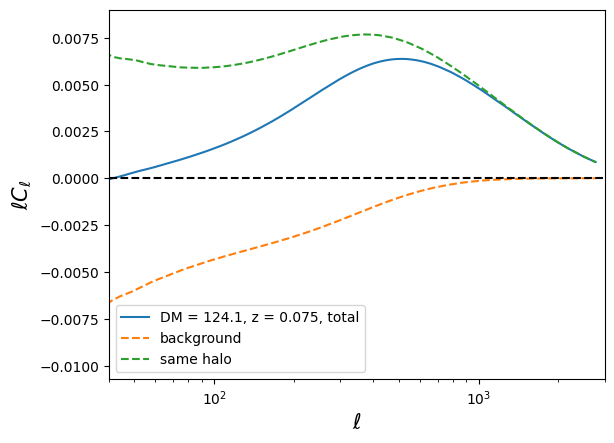

In [8]:
# mean parameter values from Kaitlyn
mu_H = 1.91/np.log10(np.e)
sig_H = 0.41/np.log10(np.e)
f.plot_single_model(0,0, np.log(mu_H), np.log(sig_H), 0, 2000, 2, -1, 0.5)

/tmp/ipykernel_2191015/3373928413.py:103: RuntimeWarning: invalid value encountered in log
  exp_aug = -((np.log(dm_H*(1+self.z_grid)) - mu_h)**2/2/(sig_h**2))


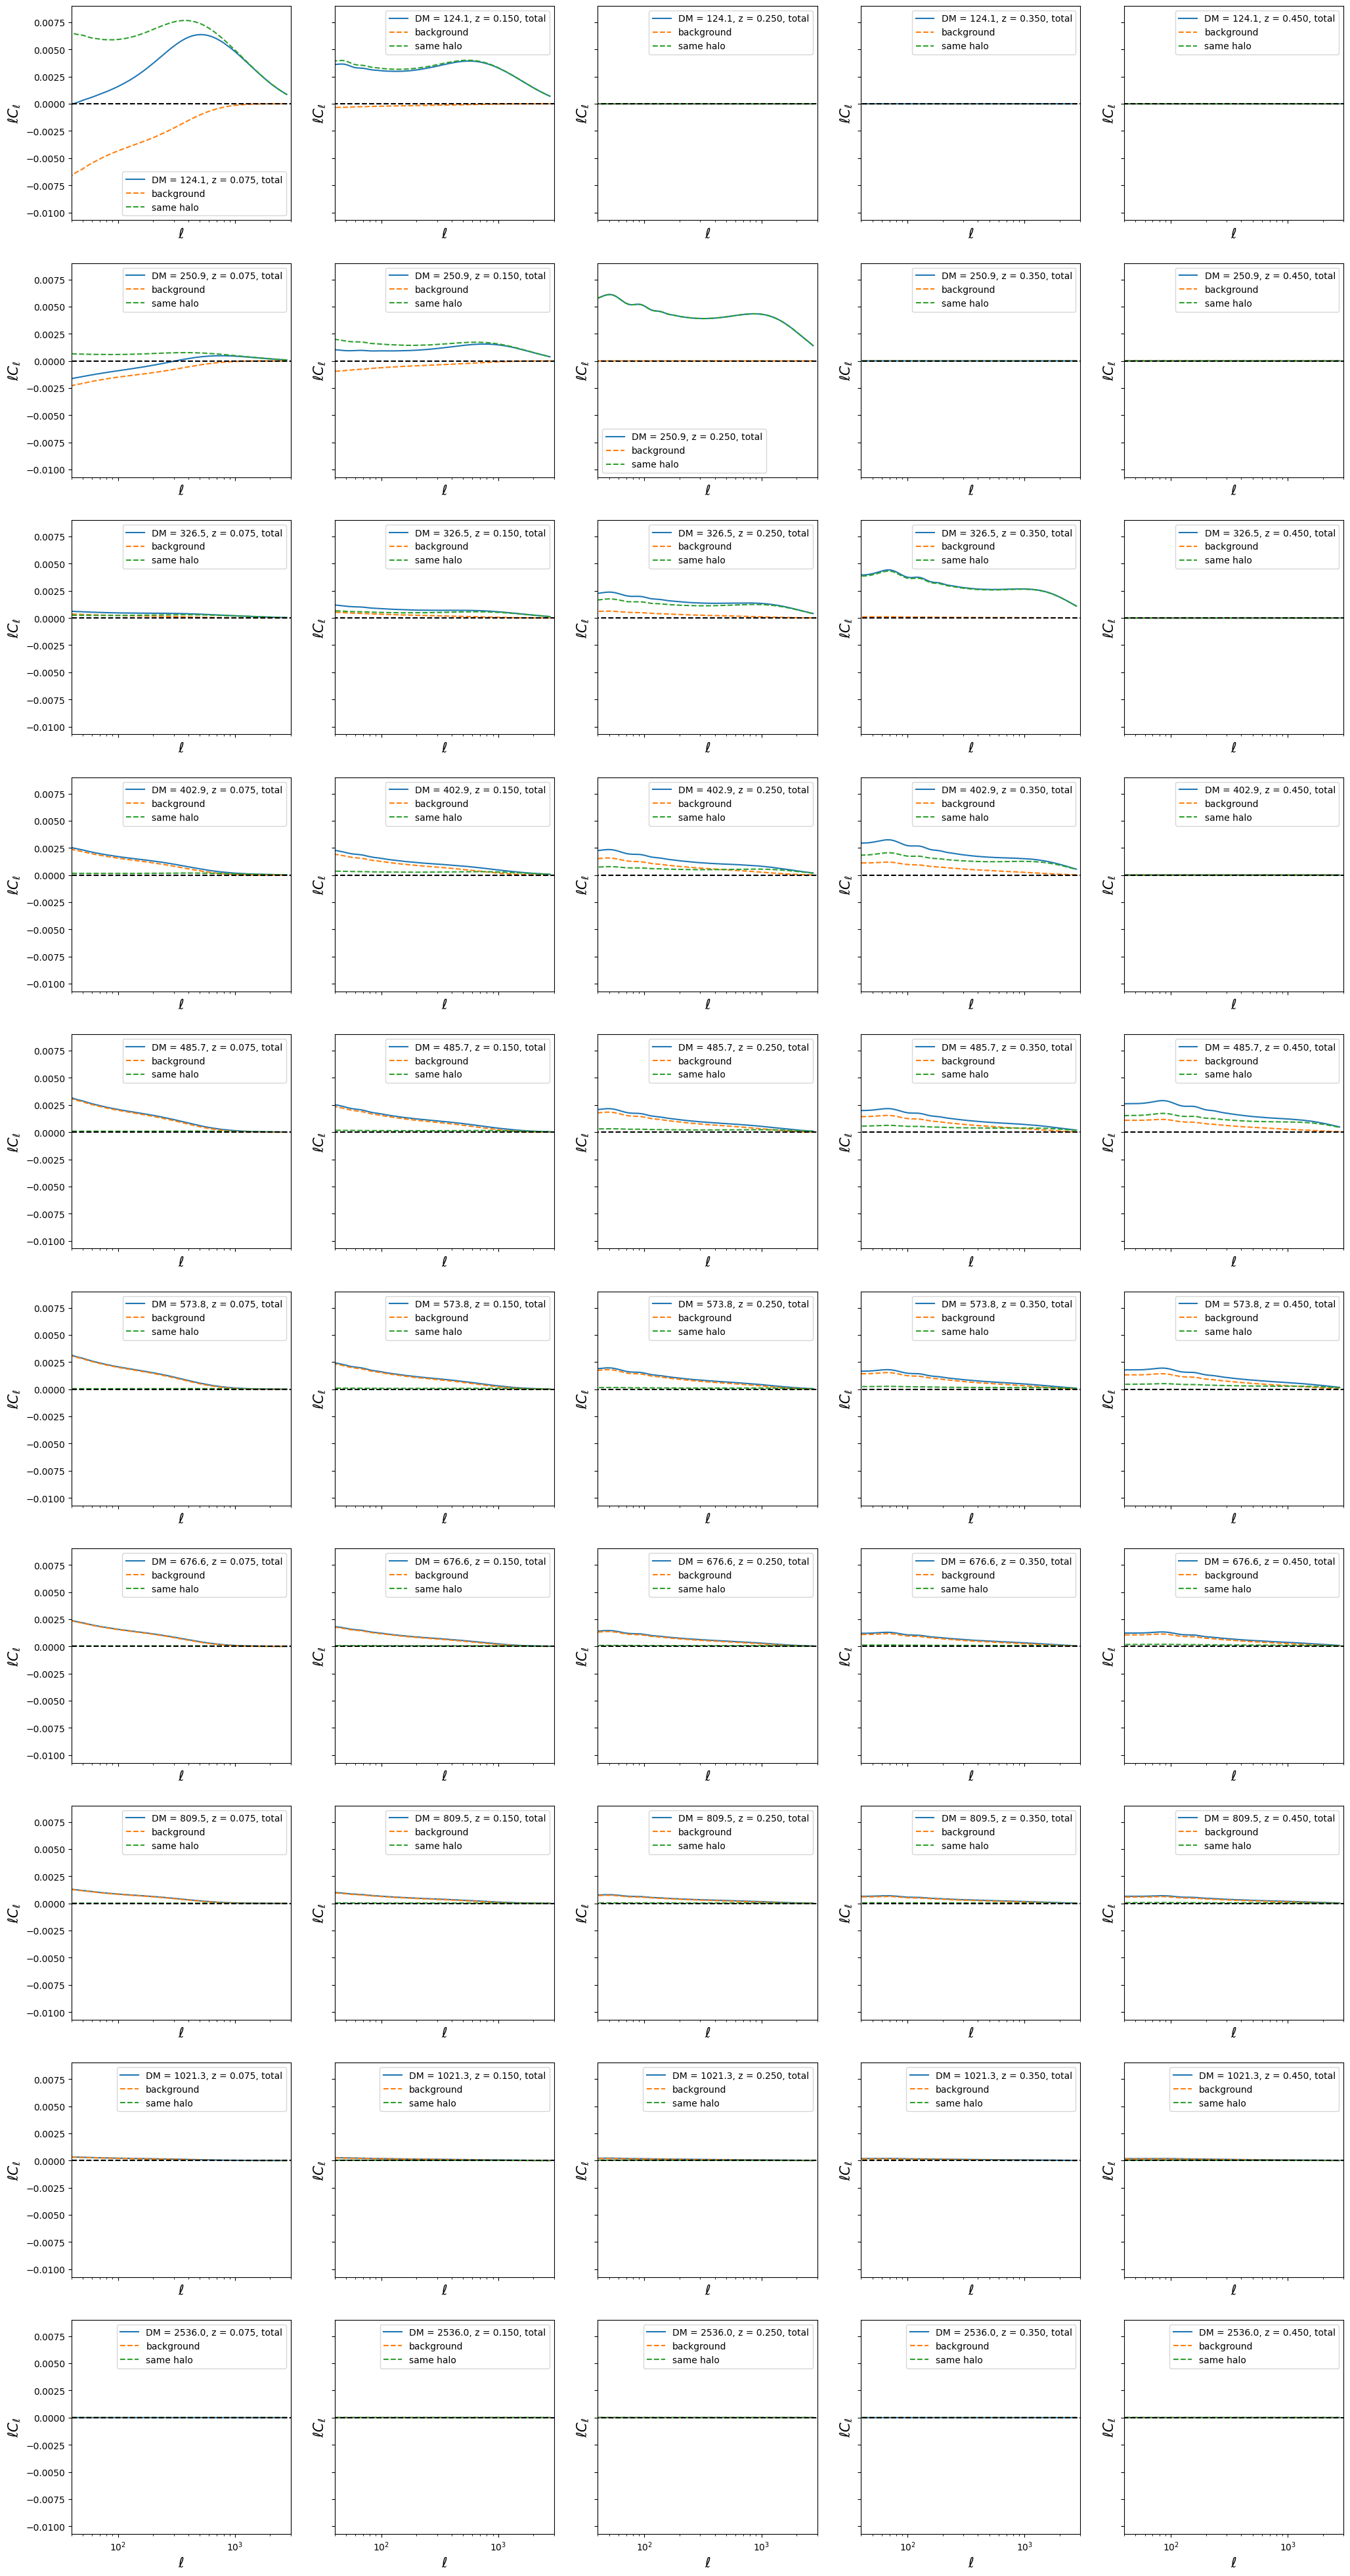

In [9]:
f.plot_full_model(np.log(mu_H), np.log(sig_H), 0, 2000, 2, -1, 0.5, (25,50))

# Fitting code

Find the prior for $\mu_h$ and $\sigma_h$ from Kaitlyn's paper

In [10]:
np.e

2.718281828459045

In [11]:
change_base = np.log10(np.e)
print('mu_h prior in natural log space:', np.log(1.30/change_base), np.log(2.70/change_base))

mu_h prior in natural log space: 1.0963967097154468 1.8272842182582394


In [12]:
# corresponding median values
print(np.exp(1.30/change_base), np.exp(2.70/change_base))

19.952623149688797 501.1872336272727


In [13]:
print('sig_h prior in natural log space:', np.log(0.04/change_base), np.log(1.74/change_base))

sig_h prior in natural log space: -2.384843379620245 1.3879175584743935


In [14]:
# Best fit results in natural log space from Kaitlyn
print(np.log(mu_H), np.log(sig_H))

1.4811356873064943 -0.057565674035827796


In [15]:
class cl_fg_fit(cl_fg_plot):

    def read_data(self, fit_file, bin_excl = 4):

        self.bin_excl = bin_excl
        
        file = h5py.File(fit_file, 'r')
        self.bin_edges = file["bin_edges"][:]
        self.lmax = file["lmax"][()]
        assert self.n_d_bins == file["n_dm_b"][()]
        assert self.nz == file['n_z_b'][()]

        self.cls_rd = np.swapaxes(file['cl'][:], 0, 1) # switch axes so 0 dim is DM, 1st dim is z
        self.errs_rd = np.swapaxes(file['error'][:], 0, 1)
        self.bin_centers_rd = file['bin_centers'][:]

        # data used for fitting (14 l bins each file)
        self.l_fit = []
        self.cl_fit = []
        self.err_fit = []
        # concatenate all values used for fitting (excluding the first 4 l bins)
        self.l_combined = [] 
        self.cl_combined = []
        self.err_combined = []

        for di in range(self.n_d_bins):

            for zi in range(self.nz):

                self.l_fit.append(self.bin_centers_rd)
                self.l_combined.extend(self.bin_centers_rd[self.bin_excl:])
 
                self.cl_fit.append(self.cls_rd[di, zi])
                self.cl_combined.extend(self.cls_rd[di, zi, self.bin_excl:])

                self.err_fit.append(self.errs_rd[di, zi])
                self.err_combined.extend(self.errs_rd[di, zi, self.bin_excl:])     
        
        self.l_data = self.l_fit[0]

        self.l_combined = np.array(self.l_combined)
        self.cl_combined = np.array(self.cl_combined)
        self.err_combined = np.array(self.err_combined)

    def plot_read_cl(self, figsize = (25, 25), exclude = True):

        if exclude == True:
            bin_start = self.bin_excl
        else:
            bin_start = 0
    
        fig, axes = plt.subplots(self.n_d_bins, self.nz, sharey=True, figsize = figsize)
        axes = np.atleast_2d(axes)

        idx = 0

        for di in range(self.n_d_bins):

            for zi in range(self.nz):
        
                    axes[di, zi].errorbar(self.l_fit[idx][bin_start:], self.l_fit[idx][bin_start:]*self.cl_fit[idx][bin_start:], yerr=self.l_fit[idx][bin_start:]*self.err_fit[idx][bin_start:], capsize=2, marker=".",
                                     label = f'DM bin {di}, z bin {zi}', linestyle = 'none')
                    axes[di, zi].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                    axes[di, zi].set_xscale("log")
                    axes[di, zi].set_xlabel(r'$\ell$', fontsize=15)
                    axes[di, zi].set_ylabel(r'$\ell C_\ell$', fontsize=15)
                    axes[di, zi].legend()

                    idx+=1
    def plot_full_model_data(self, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR, figsize = (25, 25), exclude = True):

        l = np.linspace(1, self.lmax, self.lmax)

        if exclude == True:
            bin_start = self.bin_excl
            l_start = 40
        else:
            bin_start = 0
            l_start = 1
    
        fig, ax = plt.subplots(self.n_d_bins, self.nz, sharey=True, figsize = figsize)
        ax = np.atleast_2d(ax)

        idx = 0
        
        for di in range(self.n_d_bins):

            for zi in range(self.nz):

                ax[di, zi].errorbar(self.l_fit[idx][bin_start:], self.l_fit[idx][bin_start:]*self.cl_fit[idx][bin_start:], yerr=self.l_fit[idx][bin_start:]*self.err_fit[idx][bin_start:], capsize=2, marker=".",
                                     label = f'DM bin {di}, z bin {zi}', linestyle = 'none')
                ax[di, zi].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')

                cl_fg, term1, term2 = self.model_cl_fg(l, di, zi, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR)
                
                ax[di,zi].semilogx(l, l*cl_fg, label = f"DM = {self.d_bins[di]:.1f}, z = {self.zs[zi]:.3f}, total")
                #ax[di,zi].semilogx(l, l*term1, label = f"background", linestyle = "--")
                #ax[di,zi].semilogx(l, l*term2, label = f"same halo", linestyle = "--")
                ax[di,zi].set_xscale('log')
                ax[di,zi].set_xlabel(r'$\ell$', fontsize=15)
                ax[di,zi].set_ylabel(r'$\ell C_\ell$', fontsize=15)
                ax[di,zi].legend()
                ax[di,zi].hlines(0,0,3e3, color = 'black', linestyle = 'dashed')
                ax[di,zi].set_xlim(l_start, self.lmax)

                idx+=1
    
    def combined_model(self, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR):

        cl_joint = np.array([])
        ls = np.linspace(1, self.lmax, self.lmax)

        #if self.convolve:
        #    for i in range(self.nz):
        #        cl = self.model_cl_Dg(ls, i, DM_H_bar, cut_scale, l_cut, bf0, ALPHA, Z_STAR)
        #        cl_convolve = self.cat_w[i].decouple_cell(self.cat_w[i].couple_cell([np.insert(cl,0,0)]))[0]
        #        cl_joint = np.concatenate([cl_joint, cl_convolve[self.bin_excl:]])
        #else:

        idx = 0
        
        for di in range(self.n_d_bins):
        
            for zi in range(self.nz):
                
                cl,_,_ = self.model_cl_fg(self.l_fit[idx][self.bin_excl:], di, zi, mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR)
                cl_joint = np.concatenate([cl_joint, cl])
                idx += 1

        return cl_joint

    
    # MCMC functions
    def log_likelihood(self, theta, l, Cl, err):
        
        mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR = theta
        model_Cl = self.combined_model(mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR)
        return -0.5*np.sum(((Cl - model_Cl)/err)**2 + np.log(2*np.pi*err**2))
        
    def log_prior(self, theta):
        # unnormalized prior
        mu_h, sig_h, cut_scale, l_cut, bf0, ALPHA, Z_STAR = theta
        
        if (1.096 < mu_h < 1.828) and (-2.384 < sig_h < 1.388)  and (np.log10(0.05) < cut_scale < np.log10(50)) and (300 < l_cut < 8000) and (1 < bf0 < 4) and (-2 < ALPHA < 1) and (0.1 < Z_STAR < 1.5):
            return 0.0
        return -np.inf
    
    def log_probability(self, theta, l, Cl, err):
        
        lp = self.log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf 
        return lp + self.log_likelihood(theta, l, Cl, err)

    def mcmc(self, ndim = 7, theta_init = np.array([1.48, -0.058, 1, 1500, 2, -1, 0.5]), nwalkers = 32, nsteps = 5000, thin = 20, burn_in = 3000, save = False, filename = 'mcmc_out_updated_signal_lognorm.h5'):

        assert ndim == len(theta_init)
        self.ndim = ndim
        self.theta_init = theta_init

        theta_init = self.theta_init + 1e-3 * np.random.randn(nwalkers, self.ndim)
        self.sampler = emcee.EnsembleSampler(nwalkers, self.ndim, self.log_probability, args=(self.l_combined, self.cl_combined, self.err_combined)) # self.l_combined ... come from read_data, concatenated with l bins used for fitting only 
        self.sampler.run_mcmc(theta_init, nsteps, progress=True)
        self.full_chains = self.sampler.get_chain()
        self.flat_samples = self.sampler.get_chain(discard=burn_in, thin=thin, flat=True) # technically burn-in should be 10*autocorrelation length, and thin = autocorrelation length (250)

        # Plotting
        labels = ["mu_h", "sig_h", "k_cut_inv", "l_cut", "bf", "ALPHA", "Z_STAR"]
        fig = corner.corner(self.flat_samples, labels=labels)
        fig.savefig('corner_plot_updated_signal_lognorm.pdf')
        
        # Print the median of estimated parameters
        self.muh_mc, self.sig_h_mc, self.cut_scale_mc, self.l_cut_mc, self.bf0_mc, self.ALPHA_mc, self.Z_STAR = np.median(self.flat_samples, axis=0)
        self.med_parameters = [self.muh_mc, self.sig_h_mc, self.cut_scale_mc, self.l_cut_mc, self.bf0_mc, self.ALPHA_mc, self.Z_STAR]
        print_out = f"Fitted Parameters:\nDM_H_bar = {self.muh_mc}\nsig_h = {self.sig_h_mc}\ncut_scale  = {self.cut_scale_mc}\nl_cut = {self.l_cut_mc}\nbf0 = {self.bf0_mc}\nALPHA = {self.ALPHA_mc}\nZ_STAR = {self.Z_STAR}"
        print(print_out)
        
        # likelihood ratio test (namely delta chi square test)
        # compute log_likelihood from the posterior samples
        drawn_log_likelihood = np.array([self.log_likelihood(theta, self.l_combined, self.cl_combined, self.err_combined) for theta in self.flat_samples]) 
        self.drawn_log_likelihood = drawn_log_likelihood
        max_log_likelihood = np.max(drawn_log_likelihood)
        d_M = 2*(np.mean(drawn_log_likelihood**2) - (np.mean(drawn_log_likelihood))**2)
        print("Effective degree of freedom:", d_M)
        self.max_del_chi2 = 2*(max_log_likelihood - self.log_likelihood_null(self.l_combined, self.cl_combined, self.err_combined))
        N_sig_eff = sp.stats.norm.ppf(chi2.cdf(self.max_del_chi2, round(d_M)))
        self.d_M = d_M
        print("Maximum delta chi square is", self.max_del_chi2)
        print("Effective number of sigma (likelihood ratio test):", N_sig_eff)

        max_idx = np.argmax(drawn_log_likelihood)
        self.muh_max, self.sig_h_max, self.cut_scale_max, self.l_cut_max, self.bf0_max, self.ALPHA_max, self.Z_STAR_max = self.flat_samples[max_idx,:]
        maximum_likelihood_para = [self.muh_max, self.sig_h_max, self.cut_scale_max, self.l_cut_max, self.bf0_max, self.ALPHA_max, self.Z_STAR_max]
        self.maximum_likelihood_para = maximum_likelihood_para

        if save:
            file = h5py.File(filename, 'w')
            file.create_dataset('nsteps', data = nsteps)
            file.create_dataset('nwalkers', data = nwalkers)
            file.create_dataset('burn_in', data = burn_in)
            file.create_dataset('thin', data = thin)
            file.create_dataset('full_chains', data = self.full_chains)
            file.create_dataset('flat_samples', data = self.flat_samples)
            file.create_dataset('accept_frac', data = self.sampler.acceptance_fraction)
            #file.create_dataset('autocorr_time', data = self.sampler.get_autocorr_time())
            file.create_dataset('median_parameters', data = self.med_parameters)
            file.create_dataset('parameter_names', data = labels)
            file.create_dataset('drawn_log_likelihood', data = self.drawn_log_likelihood)
            file.create_dataset('max_del_chi2', data = self.max_del_chi2)
            file.create_dataset('detection_sig', data = N_sig_eff)
            file.create_dataset('maximum_likelihood_para', data = maximum_likelihood_para)

    # evaluating detection significance
    
    def log_likelihood_null(self, l, Cl, err):
        
        model_null = np.zeros_like(l)
        return -0.5*np.sum(((Cl - model_null)/err)**2 + np.log(2*np.pi*err**2))
    
    def log_prior_null(self):
        return 0.0
    
    def log_posterior_null(self, l, Cl, err):
        return self.log_prior_null() + self.log_likelihood_null(l, Cl, err)

    def compute_chi_square_null(self, l, Cl, err):
            
        model_null = np.zeros_like(l)
        return np.sum(((Cl - model_null)/err)**2)
    
    def compute_p_val(self):
    
        self.chi_square_null = self.compute_chi_square_null(self.l_combined, self.cl_combined, self.err_combined)
        self.chi_square_best_fit = self.chi_square_null - self.max_del_chi2 
    
        from scipy.stats import chi2
        chi2_stat = self.chi_square_best_fit
        self.df = len(self.l_fit[0][self.bin_excl:])*self.nz*self.n_d_bins - self.ndim
        p_value = 1 - chi2.cdf(chi2_stat, self.df)
    
        print(f"P-value: {p_value:.5f}")

In [16]:
g = cl_fg_fit(d_bin_edge, Nd)

Note: redshifts have been re-sorted (earliest first)
5.0
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


In [17]:
ps_file = '/lustre06/project/6034496/hcwang96/frbxgal/CAT_2/first_correlation/dm_bins/10_bins/frbxgal_lmax2771_12_lb_5_zb_10_db_100_samplessecond_try.h5'
g.read_data(ps_file)

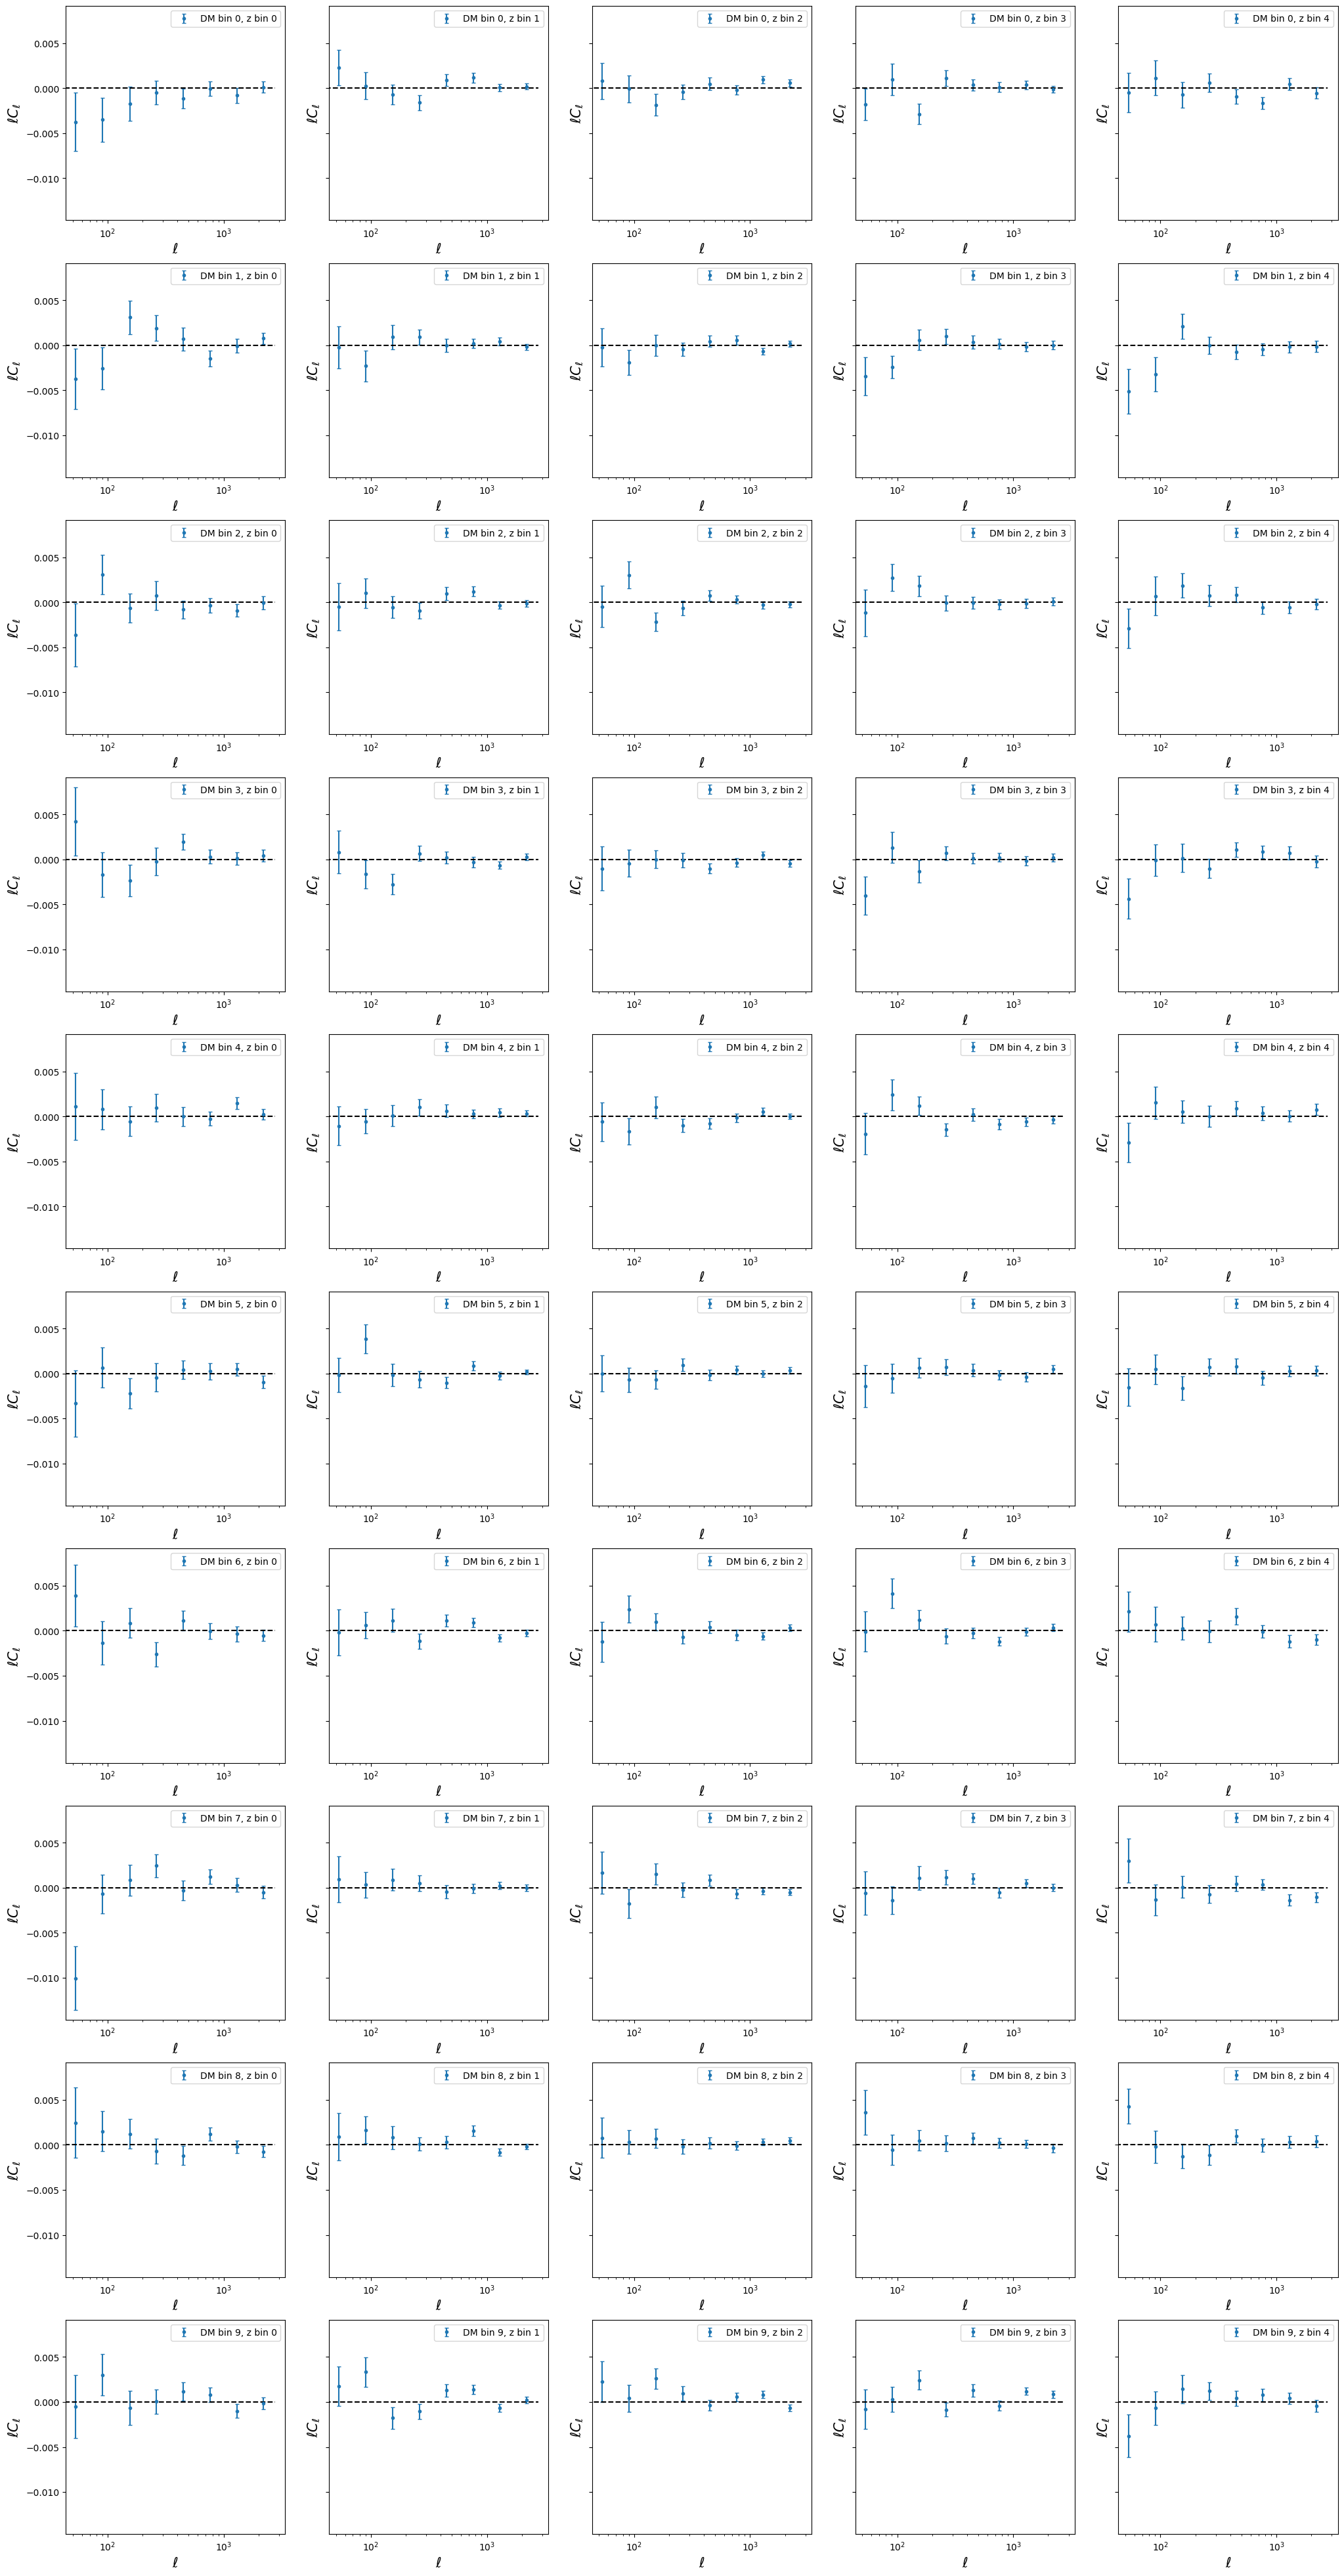

In [18]:
g.plot_read_cl(figsize = (25, 50))

/tmp/ipykernel_2191015/3373928413.py:103: RuntimeWarning: invalid value encountered in log
  exp_aug = -((np.log(dm_H*(1+self.z_grid)) - mu_h)**2/2/(sig_h**2))
100%|██████████| 5000/5000 [7:30:33<00:00,  5.41s/it]  


Fitted Parameters:
DM_H_bar = 1.6307350029347498
sig_h = 0.40339820063408394
cut_scale  = -0.01164814792660528
l_cut = 1753.4961758871764
bf0 = 1.6034403656809746
ALPHA = -0.39153972459971326
Z_STAR = 1.346039214642408


/tmp/ipykernel_2191015/3373928413.py:103: RuntimeWarning: invalid value encountered in log
  exp_aug = -((np.log(dm_H*(1+self.z_grid)) - mu_h)**2/2/(sig_h**2))


Effective degree of freedom: 9.503303833305836
Maximum delta chi square is 19.5648212443175
Effective number of sigma (likelihood ratio test): 1.8296911666112594


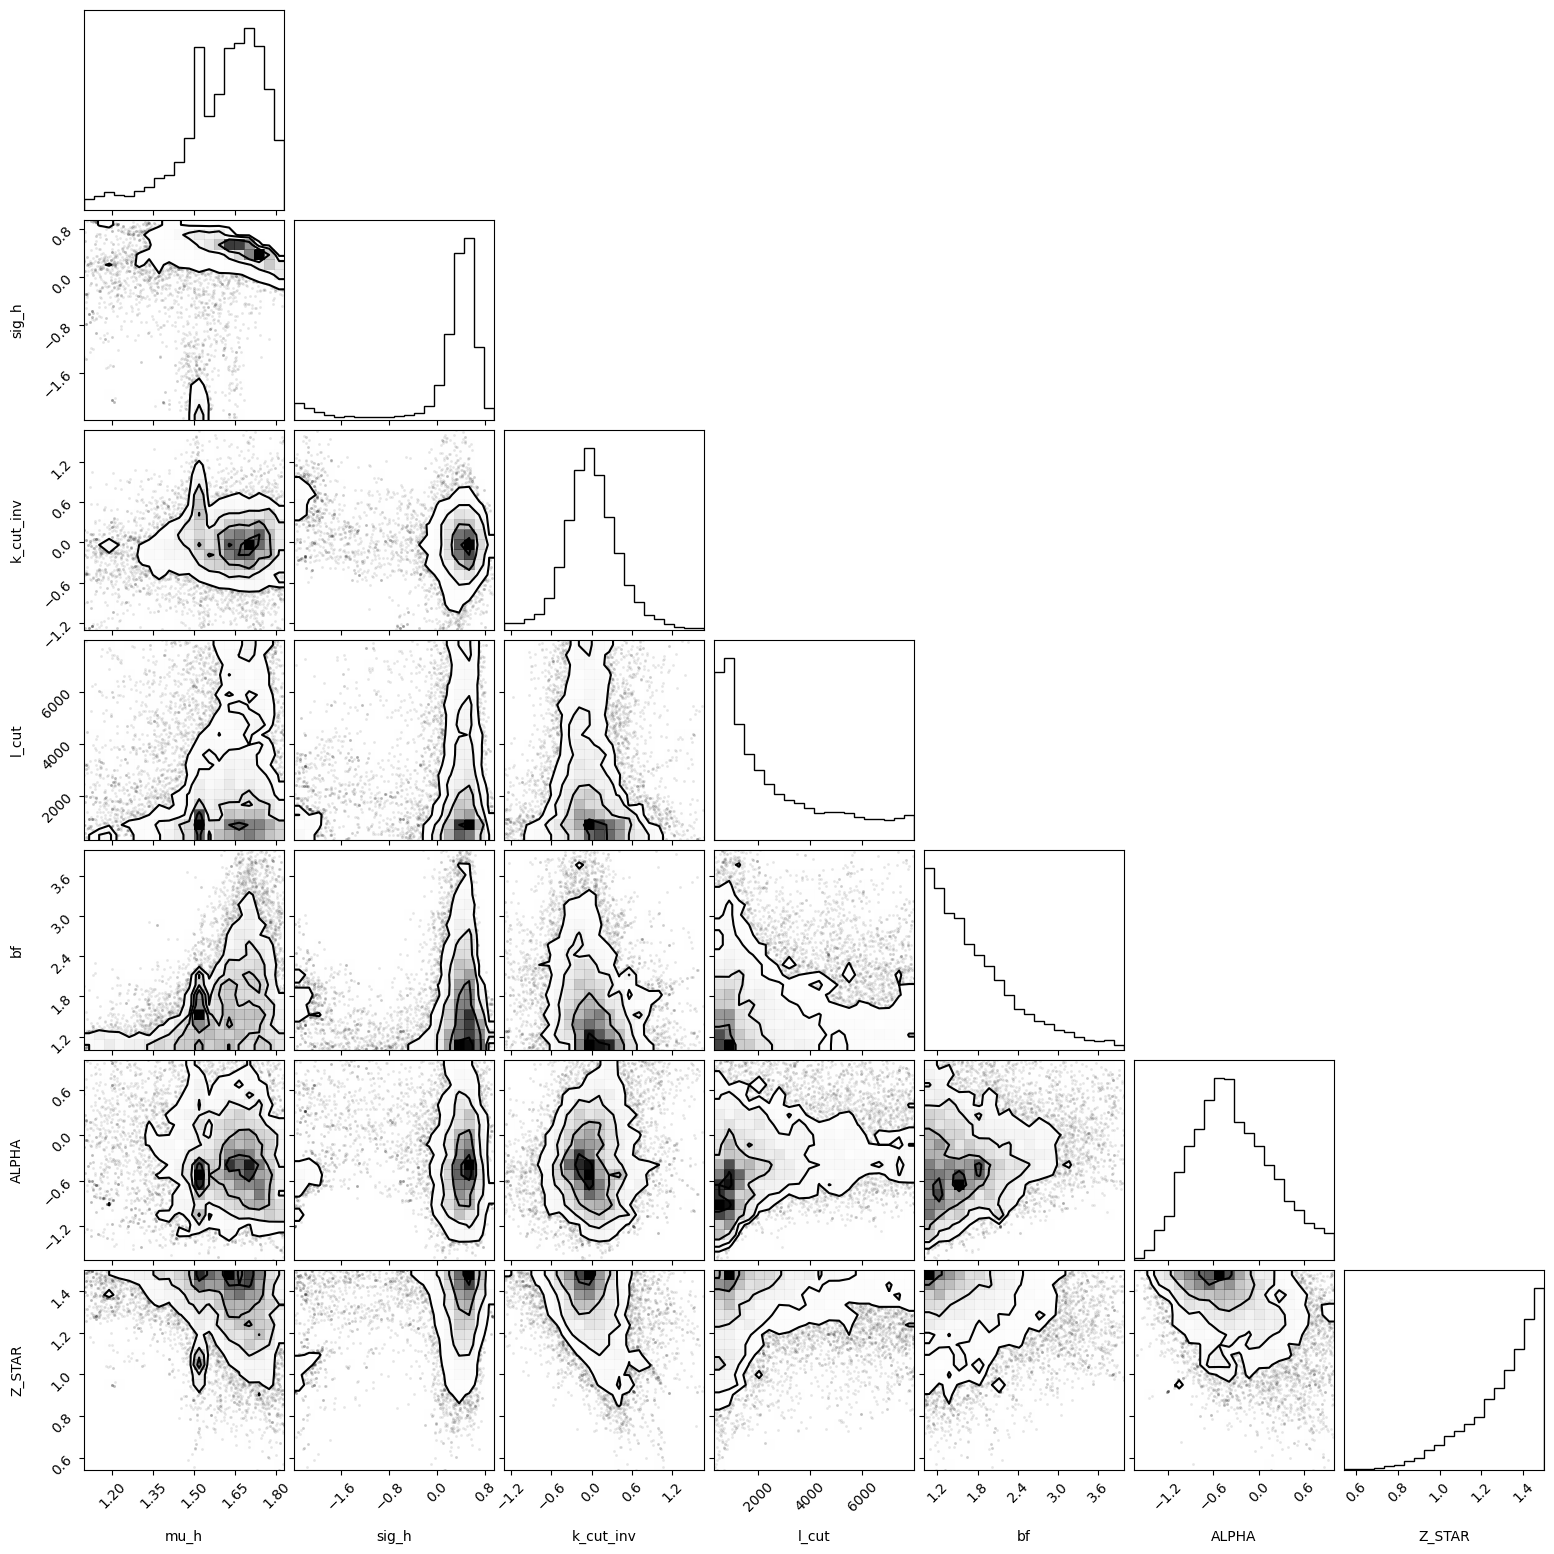

In [19]:
g.mcmc(save = True, thin = 10, burn_in = 1000, nsteps = 5000, filename = 'mcmc_out_updated_signal_lognorm_10bins_small_mcmc_sample.h5')

### Adding some methods

In [20]:
import types

def compute_chi_square_null(self, l, Cl, err):
        
    model_null = np.zeros_like(l)
    return np.sum(((Cl - model_null)/err)**2)

def compute_p_val(self):

    self.chi_square_null = self.compute_chi_square_null(self.l_combined, self.cl_combined, self.err_combined)
    self.chi_square_best_fit = self.chi_square_null - self.max_del_chi2 

    from scipy.stats import chi2
    chi2_stat = self.chi_square_best_fit
    self.df = len(self.l_fit[0][self.bin_excl:])*self.nz*self.n_d_bins - self.ndim
    p_value = 1 - chi2.cdf(chi2_stat, self.df)

    print(f"P-value: {p_value:.5f}")

g.compute_chi_square_null = types.MethodType(compute_chi_square_null, g)
g.compute_p_val = types.MethodType(compute_p_val, g)

In [21]:
import types
def plot_full_model_data(self, dh, sigmah, cut_scale, l_cut, bf0, ALPHA, Z_STAR, figsize = (25, 25), exclude = True):

        l = np.linspace(1, self.lmax, self.lmax)

        if exclude == True:
            bin_start = self.bin_excl
            l_start = 40
        else:
            bin_start = 0
            l_start = 1
    
        fig, ax = plt.subplots(self.n_d_bins, self.nz, sharey=True, figsize = figsize)
        ax = np.atleast_2d(ax)

        idx = 0
        
        for di in range(self.n_d_bins):

            for zi in range(self.nz):

                ax[di, zi].errorbar(self.l_fit[idx][bin_start:], self.l_fit[idx][bin_start:]*self.cl_fit[idx][bin_start:], yerr=self.l_fit[idx][bin_start:]*self.err_fit[idx][bin_start:], capsize=2, marker=".",
                                     label = f'DM bin {di}, z bin {zi}', linestyle = 'none')
                ax[di, zi].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')

                cl_fg, term1, term2 = self.model_cl_fg(l, di, zi, dh, sigmah, cut_scale, l_cut, bf0, ALPHA, Z_STAR)
                
                ax[di,zi].semilogx(l, l*cl_fg, label = f"DM = {self.d_bins[di]:.1f}, z = {self.zs[zi]:.3f}, total")
                ax[di,zi].semilogx(l, l*term1, label = f"background", linestyle = "--")
                ax[di,zi].semilogx(l, l*term2, label = f"same halo", linestyle = "-.")
                ax[di,zi].set_xscale('log')
                ax[di,zi].set_xlabel(r'$\ell$', fontsize=15)
                ax[di,zi].set_ylabel(r'$\ell C_\ell$', fontsize=15)
                ax[di,zi].legend()
                ax[di,zi].hlines(0,0,3e3, color = 'black', linestyle = 'dashed')
                ax[di,zi].set_xlim(l_start, self.lmax)

                idx+=1
g.plot_full_model_data = types.MethodType(plot_full_model_data, g)

### Median values

In [22]:
print(g.med_parameters)

[1.6307350029347498, 0.40339820063408394, -0.01164814792660528, 1753.4961758871764, 1.6034403656809746, -0.39153972459971326, 1.346039214642408]


/tmp/ipykernel_2191015/3373928413.py:103: RuntimeWarning: invalid value encountered in log
  exp_aug = -((np.log(dm_H*(1+self.z_grid)) - mu_h)**2/2/(sig_h**2))


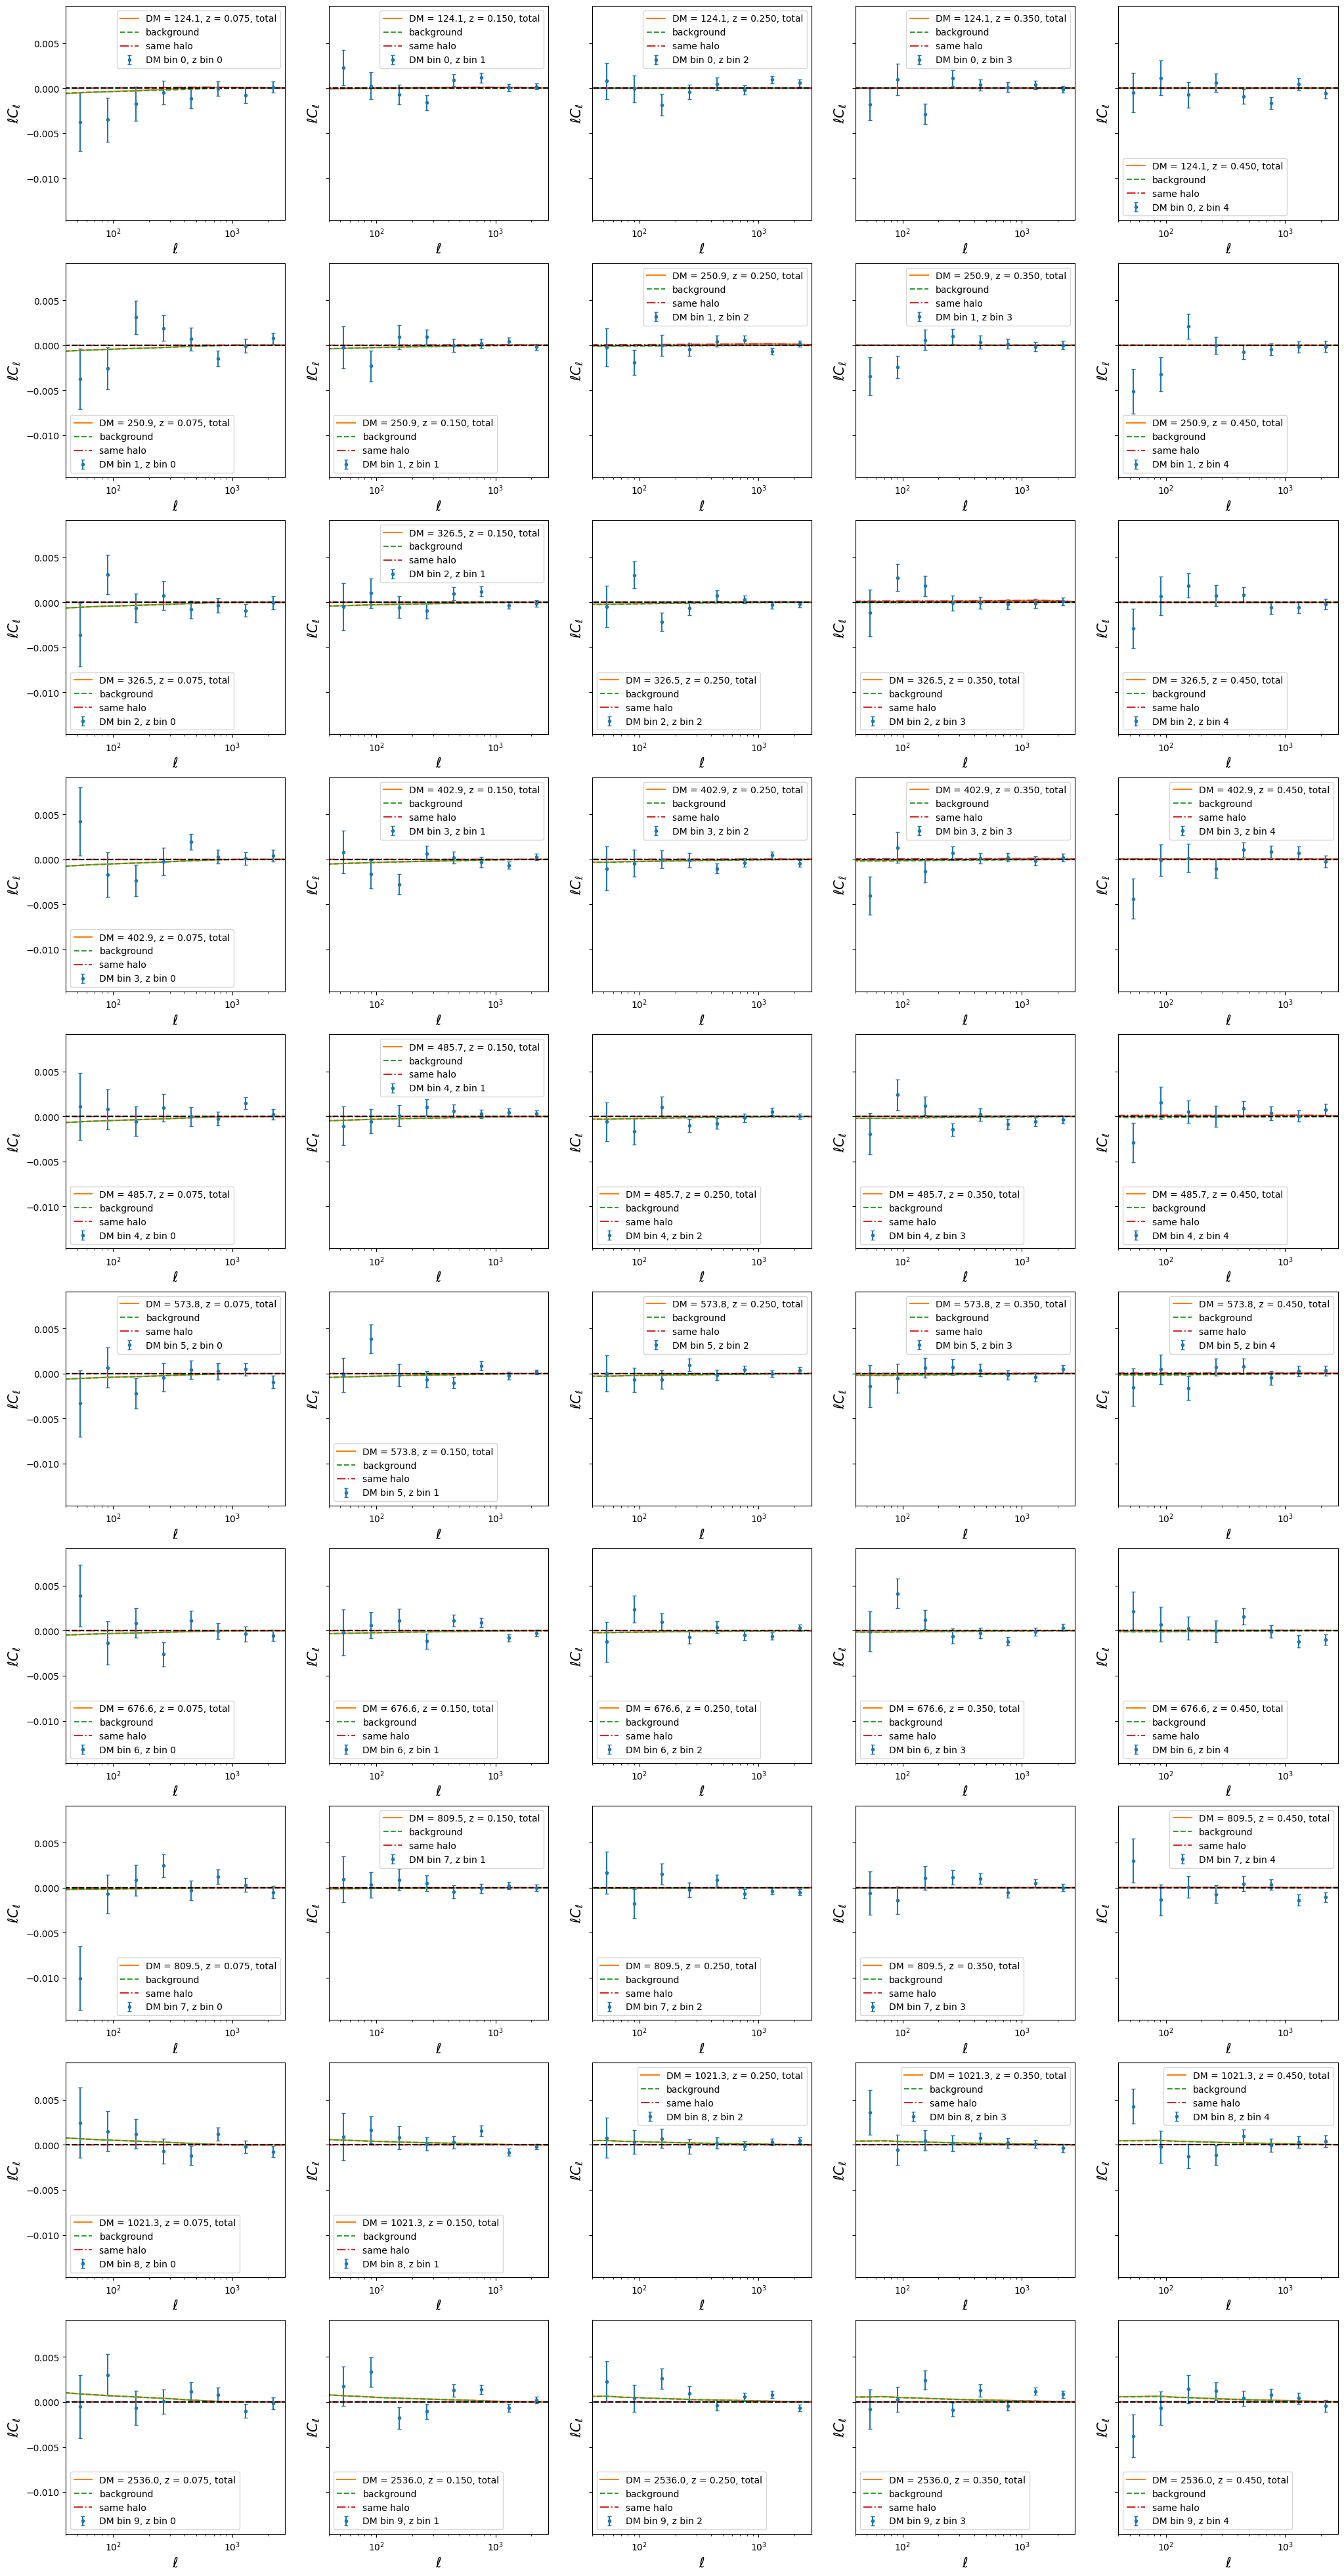

In [26]:
g.plot_full_model_data(*g.med_parameters, figsize = (25, 50))

Host DM distribution

In [24]:
mu_h_med = np.exp(g.muh_mc)
sig_h_med = np.exp(g.sig_h_mc)

In [25]:
host_med = res_DM_prob_lognorm(mu_h_med, sig_h_med)

NameError: name 'res_DM_prob_lognorm' is not defined

In [ ]:
_,_ = host_med.plot_DM_H_prob(z = [0], d_grid = np.linspace(0, 500, 1000))

In [ ]:
print('Mean host DM is', host_med.mean_DM_H_z(z=0), 'pc cm-3')

In [ ]:
np.exp(mu_h_med)

FRB redshift distribution

In [ ]:
Nf = 2873
red_med = dim_pf_chi(Nf, g.ALPHA_mc, g.Z_STAR)

In [ ]:
plt.plot(red_med.z_grid, red_med.pf_z)
plt.title(r"$P_f(z)$")

FRB DM distribution

In [ ]:
frb_path = "/lustre06/project/6034496/hcwang96/frbxgal/CAT_2/cat_2_repeater_once_DM100_cut.h5"
frb_file = h5py.File(frb_path, 'r')
cat2_dm = frb_file['dm_obs'][:]
Nf = len(cat2_dm)

dm_grid = np.linspace(0, np.max(cat2_dm), 1000)
#pdf = P_DM(dm_grid)

_,bin_edge,_ = plt.hist(cat2_dm, bins=30, edgecolor='k', alpha=0.7)
#plt.plot(dm_grid, pdf*Nf*(bin_edge[1] - bin_edge[0]))
plt.xlabel("DM [pc cm^-2]")
plt.ylabel("FRB number counts")

In [ ]:
p_dm = np.zeros_like(dm_grid)

for i, this_dm in enumerate(dm_grid):
    p_dm_z = host_med.cap_P_vector(this_dm - g.D_bar, g.z_grid)
    p_dm[i] = trapezoid(p_dm_z*red_med.pf_z, g.z_grid)

In [ ]:
plt.plot(dm_grid, p_dm)

In [ ]:
_,bin_edge,_ = plt.hist(cat2_dm, bins=30, edgecolor='k', alpha=0.7, label = 'data')
plt.plot(dm_grid, p_dm*Nf*(bin_edge[1] - bin_edge[0]), label = 'model')
plt.xlabel("DM [pc cm^-2]")
plt.ylabel("FRB number counts")
plt.legend()

### Maximum likelihood values

In [ ]:
g.maximum_likelihood_para = [g.muh_max, g.sig_h_max, g.cut_scale_max, g.l_cut_max, g.bf0_max, g.ALPHA_max, g.Z_STAR_max]

In [ ]:
print(g.maximum_likelihood_para)

In [ ]:
g.compute_p_val()

In [ ]:
g.chi_square_best_fit/g.df

In [ ]:
g.plot_full_model_data(*g.maximum_likelihood_para)

Host DM distribution

In [ ]:
mu_h_max = np.exp(g.muh_max)
sig_h_max = np.exp(g.sig_h_max)

In [ ]:
host_max = res_DM_prob_lognorm(mu_h_max, sig_h_max)

In [ ]:
_,_ = host_max.plot_DM_H_prob(z = [0], d_grid = np.linspace(0, 500, 1000))

In [ ]:
print('Mean host DM is', host_max.mean_DM_H_z(z=0), 'pc cm-3')

In [ ]:
print('Median host DM is', np.exp(mu_h_max), 'pc cm-3')

FRB redshift distribution

In [ ]:
red_max = dim_pf_chi(Nf, g.ALPHA_max, g.Z_STAR_max)

In [ ]:
plt.plot(red_max.z_grid, red_max.pf_z)
plt.title(r"$P_f(z)$")

FRB DM distribution

In [ ]:
p_dm_max = np.zeros_like(dm_grid)

for i, this_dm in enumerate(dm_grid):
    p_dm_z_max = host_max.cap_P_vector(this_dm - g.D_bar, g.z_grid)
    p_dm_max[i] = trapezoid(p_dm_z_max*red_max.pf_z, g.z_grid)

In [ ]:
_,bin_edge,_ = plt.hist(cat2_dm, bins=30, edgecolor='k', alpha=0.7, label = 'data')
plt.plot(dm_grid, p_dm_max*Nf*(bin_edge[1] - bin_edge[0]), label = 'model')
plt.xlabel("DM [pc cm^-2]")
plt.ylabel("FRB number counts")
plt.legend()

In [ ]:
np.round(6.447966771200299)

### Save the outputs to my home directory for now

In [94]:
file = h5py.File('mcmc_out_updated_signal_lognormal.h5', 'w')
file.create_dataset('nsteps', data = 30000)
file.create_dataset('nwalkers', data = 32)
file.create_dataset('burn_in', data = 3000)
file.create_dataset('thin', data = 20)
file.create_dataset('full_chains', data = g.full_chains)
file.create_dataset('flat_samples', data = g.flat_samples)
file.create_dataset('accept_frac', data = g.sampler.acceptance_fraction)
#file.create_dataset('autocorr_time', data = g.sampler.get_autocorr_time())
file.create_dataset('median_parameters', data = g.med_parameters)
file.create_dataset('parameter_names', data = ["mu_h", "sig_h", "k_cut_inv", "l_cut", "bf", "ALPHA", "Z_STAR"])
file.create_dataset('drawn_log_likelihood', data = g.drawn_log_likelihood)
file.create_dataset('max_del_chi2', data = g.max_del_chi2)
file.create_dataset('detection_sig', data = 2.6180116062858514)
file.create_dataset('maximum_likelihood_para', data = g.maximum_likelihood_para)
file.close()

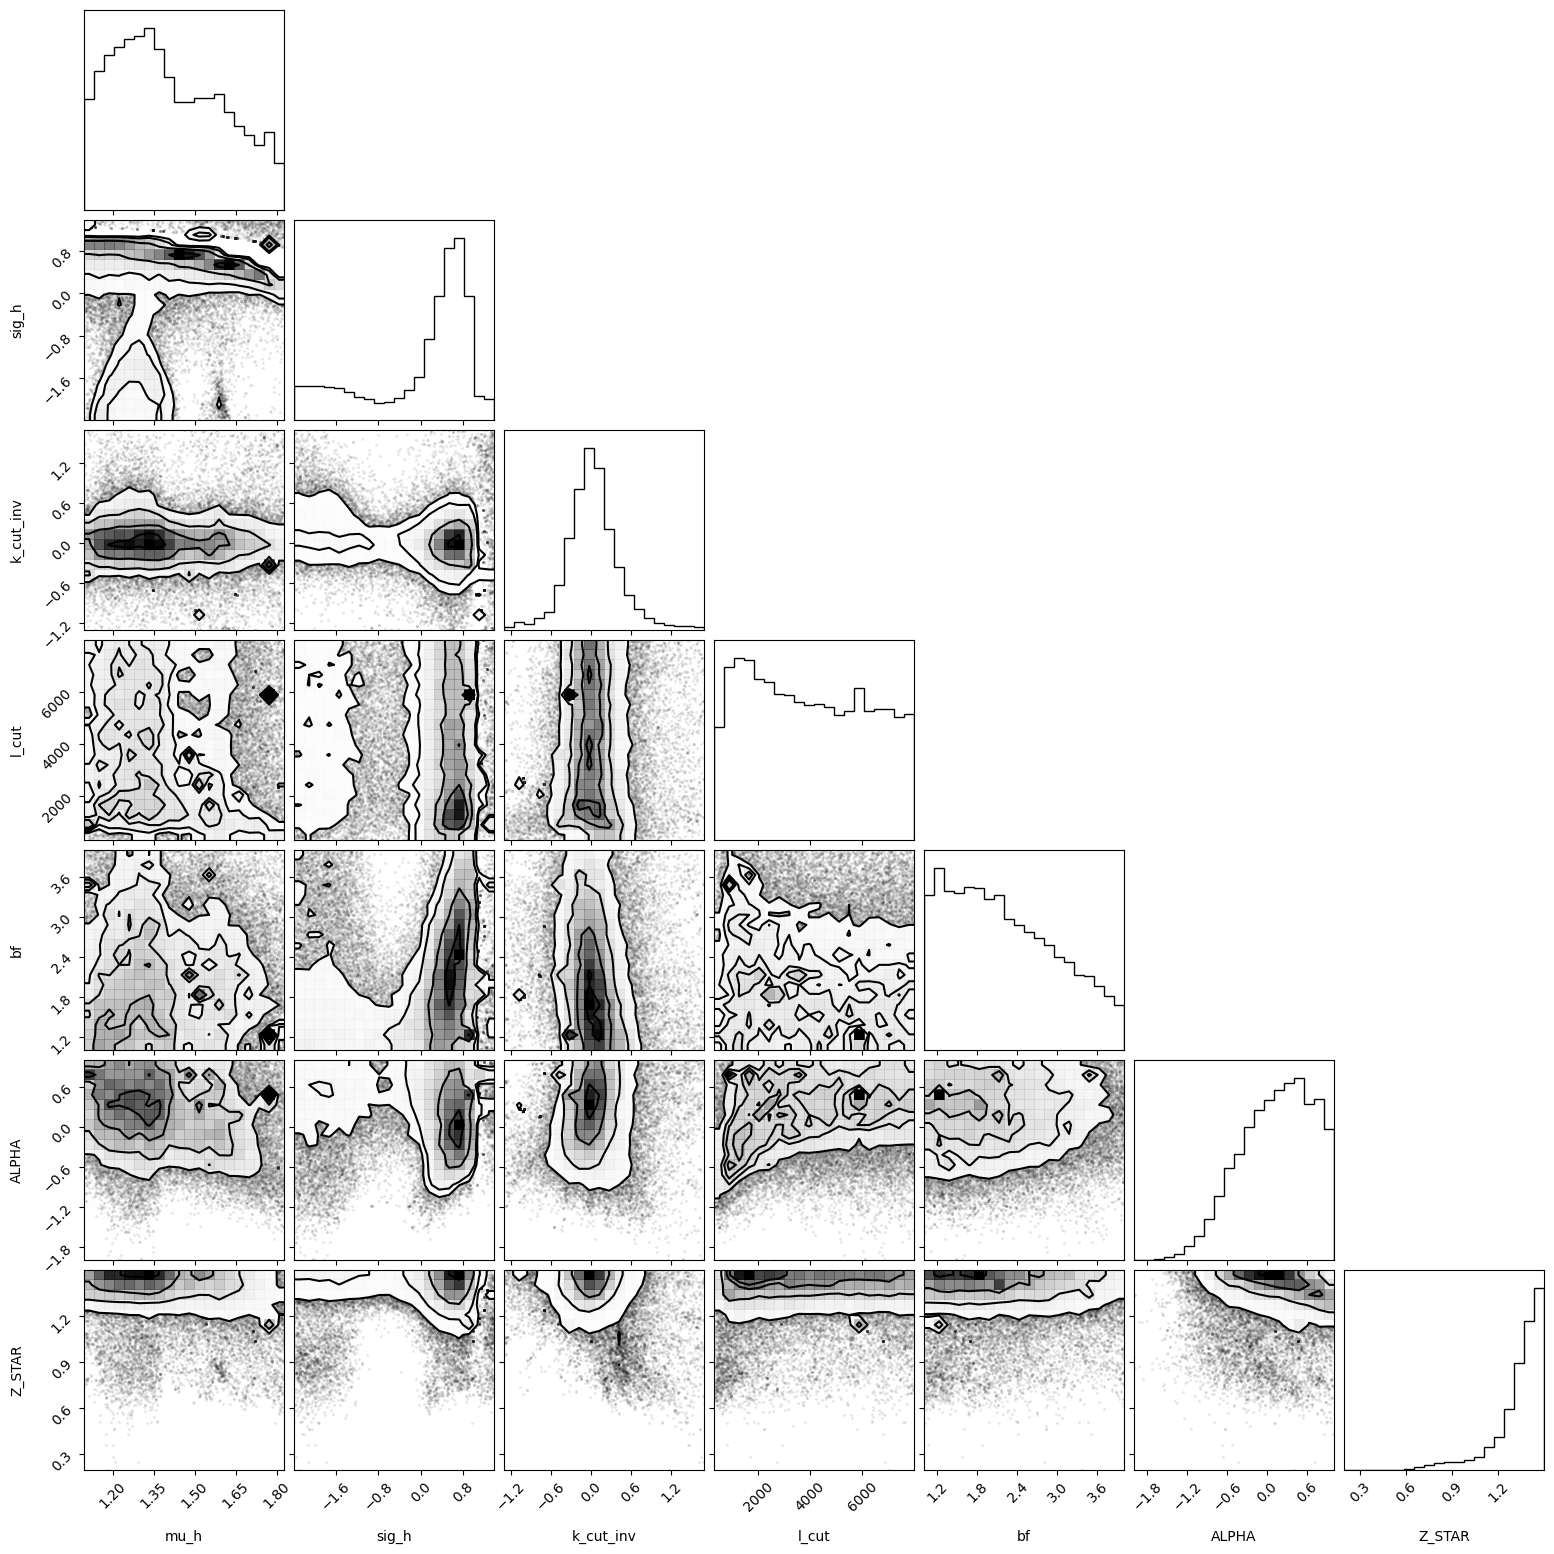

In [95]:
fig = corner.corner(g.flat_samples, labels=["mu_h", "sig_h", "k_cut_inv", "l_cut", "bf", "ALPHA", "Z_STAR"])
fig.savefig('corner_plot_updated_signal_lognorm.pdf')